# 🦗 02 — Feature Extraction
สกัด Feature Vector จากทุก audio segment แล้ว save เป็น 

**เป้าหมาย:** สร้าง feature matrix พร้อมสำหรับ UMAP + HDBSCAN


In [ ]:
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from cricket_perception.audio_utils import load_audio, segment_audio, denoise_audio
from cricket_perception.features import FeatureExtractor

plt.style.use("dark_background")
print(" Imports OK")


✅ Imports OK


## Config

In [2]:
DATASET_DIR = Path("../dataset/insectset32/Orthoptera/Orthoptera")
CACHE_DIR     = Path("../features_cache")
CACHE_DIR.mkdir(exist_ok=True)

SR            = 22_050
SEGMENT_SEC   = 5.0    # length of each analysis window
HOP_SEC       = 2.5    # 50% overlap
APPLY_DENOISE = True   # set False to skip denoising (faster)

extractor = FeatureExtractor(
    sr=SR,
    n_mfcc=13,
    use_mfcc=True,
    use_spectral=True,
    use_chroma_zcr=True,
    use_rms=True,
    use_aci=True,
    use_melspec=False,
)
print(f"Feature dimension: {extractor.feature_dim}")


Feature dimension: 53


## Extract Features from All Files

In [4]:
audio_files = sorted(DATASET_DIR.rglob("*.wav")) + sorted(DATASET_DIR.rglob("*.flac"))
print(f"Processing {len(audio_files)} files...")

all_features = []
all_meta     = []

for audio_path in tqdm(audio_files, desc="Files"):
    try:
        y, sr = load_audio(audio_path, sr=SR)
        if APPLY_DENOISE:
            y = denoise_audio(y, sr)
        segments = segment_audio(y, sr, segment_sec=SEGMENT_SEC, hop_sec=HOP_SEC)
        for i, seg in enumerate(segments):
            vec = extractor.extract(seg)
            all_features.append(vec)
            all_meta.append({
                "file":    str(audio_path.relative_to(DATASET_DIR)),
                "species": audio_path.parent.name,
                "segment": i,
                "start_s": i * HOP_SEC,
            })
    except Exception as e:
        print(f"   Skipping {audio_path.name}: {e}")

X = np.stack(all_features).astype(np.float32)
df_meta = pd.DataFrame(all_meta)
print(f"Feature matrix: {X.shape}")
print(f"   Species: {df_meta.species.nunique()}")
print(f"   Segments: {len(df_meta)}")


Processing 147 files...


Files:   0%|          | 0/147 [00:00<?, ?it/s]

Feature matrix: (759, 53)
   Species: 9
   Segments: 759


## Save to Cache

In [5]:
np.save(CACHE_DIR / "features_X.npy", X)
df_meta.to_csv(CACHE_DIR / "features_meta.csv", index=False)
print(f"Saved:")
print(f"   {CACHE_DIR}/features_X.npy    ({X.nbytes/1e6:.1f} MB)")
print(f"   {CACHE_DIR}/features_meta.csv")


Saved:
   ../features_cache/features_X.npy    (0.2 MB)
   ../features_cache/features_meta.csv


## Feature Distribution Check

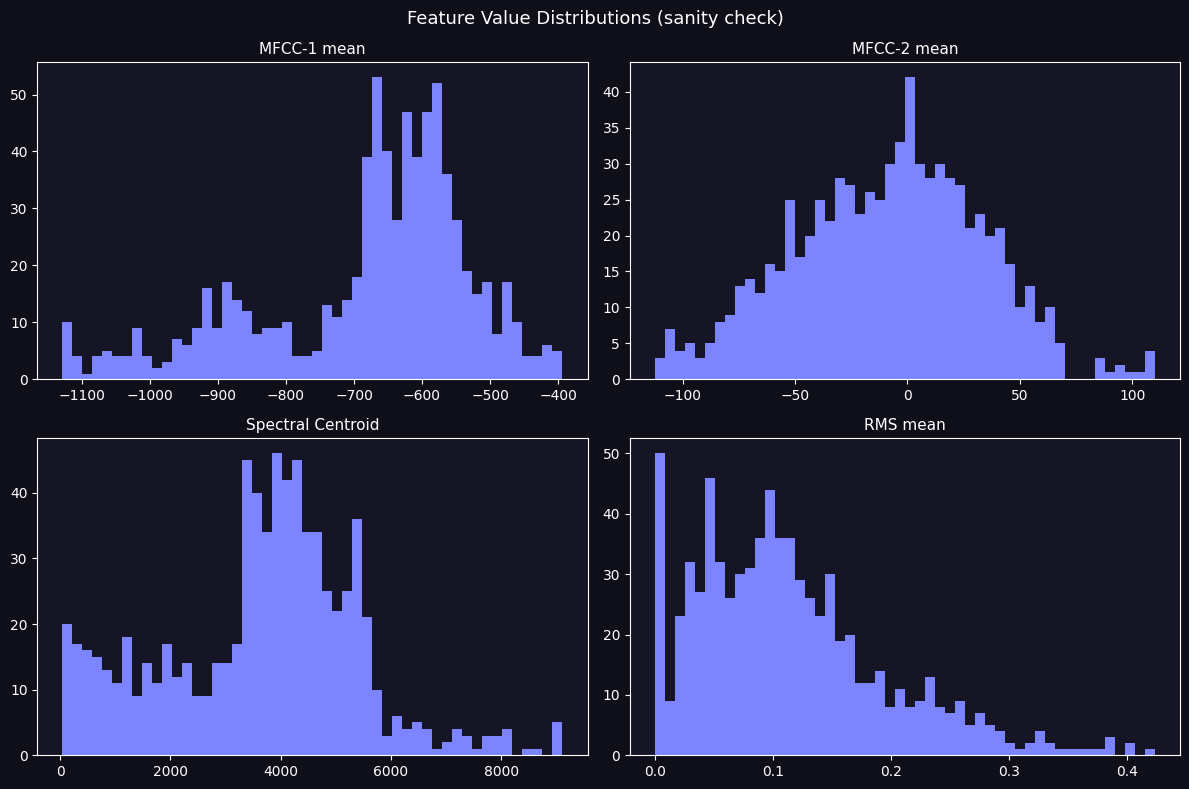

In [6]:
# Quick sanity: plot distribution of first 4 features
fig, axes = plt.subplots(2, 2, figsize=(12, 8), facecolor="#0f0f1a")
feature_names = ["MFCC-1 mean", "MFCC-2 mean", "Spectral Centroid", "RMS mean"]
feat_indices  = [0, 1, 26, 47]  # adjust if feature_dim changes

for ax, name, idx in zip(axes.flat, feature_names, feat_indices):
    ax.set_facecolor("#151525")
    ax.tick_params(colors="white")
    if idx < X.shape[1]:
        ax.hist(X[:, idx], bins=50, color="#7c85ff", edgecolor="none")
    ax.set_title(name, color="white", fontsize=11)

plt.suptitle("Feature Value Distributions (sanity check)",
             color="white", fontsize=13)
plt.tight_layout()
plt.savefig("../results/02_feature_distributions.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
